In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Make tables easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [1]:
# =========================
# 2. LOAD THE DATASET
# =========================
# The dataset has a blank first row, so skiprows=1 is used

df_raw = pd.read_csv("Internship casestudy week 2.csv", skiprows=1)
df_raw.head()

NameError: name 'pd' is not defined

In [ ]:

# Clean column names
df = df_raw.copy()
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [ ]:
# Remove duplicate columns by name
df = df.loc[:, ~df.columns.duplicated()]

# Drop duplicated waiting time column if present
if "courier_waiting_time_mins.1" in df.columns:
    df = df.drop(columns=["courier_waiting_time_mins.1"])

print("Cleaned column names:")
print(df.columns.tolist())

In [ ]:
# Clean currency columns by removing € and converting to numeric
currency_cols = ["basket_size", "delivery_fee", "cost_per_order_cpo", "distance_in_km_pick_up_to_delivery"]

for col in currency_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("€", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert other fields to the right type
df["courier_waiting_time_mins"] = pd.to_numeric(df["courier_waiting_time_mins"], errors="coerce")
df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce")
df["store_code"] = df["store_code"].astype(str)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Fill missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median(numeric_only=True))

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df = df.drop_duplicates()
print("\nShape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isna().sum())

display(df.head())



In [ ]:
# =========================
# 4. FEATURE ENGINEERING
# =========================

# Create helpful business features
df["fee_minus_cpo"] = df["delivery_fee"] - df["cost_per_order_cpo"]

# Order volume per store is used as a simple proxy for operational load
df["order_volume_store"] = df.groupby(["city", "store_code"])["order_id"].transform("count")

# Date based feature
df["day_of_week"] = df["date"].dt.dayofweek

# Distance band
df["distance_band"] = pd.cut(
    df["distance_in_km_pick_up_to_delivery"],
    bins=[-0.001, 2, 5, 10, 50],
    labels=["0-2km", "2-5km", "5-10km", "10km+"]
)
# Basket band
df["basket_band"] = pd.cut(
    df["basket_size"],
    bins=[-0.001, 10, 20, 40, 1000],
    labels=["0-10€", "10-20€", "20-40€", "40€+"]
)

print("\nFeature engineering completed.")
display(df.head())

In [ ]:
# ============================================================
#  COST PREDICTION ENGINE
# Goal: Predict Cost per Order (CPO)
# ============================================================

# Features selected for cost prediction
cost_features = [
    "city",
    "store_code",
    "basket_size",
    "delivery_fee",
    "distance_in_km_pick_up_to_delivery",
    "day_of_week",
    "order_volume_store"
]

cost_target = "cost_per_order_cpo"

X_cost = df[cost_features].copy()
y_cost = df[cost_target].copy()
categorical_features = ["city", "store_code"]
numeric_features = [
    "basket_size",
    "delivery_fee",
    "distance_in_km_pick_up_to_delivery",
    "day_of_week",
    "order_volume_store"
]
categorical_features = ["city", "store_code"]
numeric_features = [
    "basket_size",
    "delivery_fee",
    "distance_in_km_pick_up_to_delivery",
    "day_of_week",
    "order_volume_store"
]



In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
# Random Forest model
cost_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

cost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", cost_model)
    ]
)


In [ ]:
# Split data
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cost, y_cost, test_size=0.2, random_state=42
)

# Train model
cost_pipeline.fit(Xc_train, yc_train)


In [ ]:
# Predict
cost_pred = cost_pipeline.predict(Xc_test)

# Evaluate
cost_mae = mean_absolute_error(yc_test, cost_pred)
cost_r2 = r2_score(yc_test, cost_pred)

print("\nCOST PREDICTION ENGINE PERFORMANCE")
print("MAE:", round(cost_mae, 3))
print("R²:", round(cost_r2, 3))

In [ ]:
# ============================================================
#  WAITING TIME PREDICTION MODEL
# Goal: Predict courier waiting time
# ============================================================

In [18]:
wait_features = cost_features
wait_target = "courier_waiting_time_mins"

X_wait = df[wait_features].copy()
y_wait = df[wait_target].copy()

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wait, y_wait, test_size=0.2, random_state=42
)

wait_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3
)

wait_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", wait_model)
    ]
)


In [19]:
# Train model
wait_pipeline.fit(Xw_train, yw_train)

# Predict
wait_pred = wait_pipeline.predict(Xw_test)

# Evaluate
wait_mae = mean_absolute_error(yw_test, wait_pred)
wait_r2 = r2_score(yw_test, wait_pred)

print("\nWAITING TIME PREDICTION MODEL PERFORMANCE")
print("MAE:", round(wait_mae, 3))
print("R²:", round(wait_r2, 3))


WAITING TIME PREDICTION MODEL PERFORMANCE
MAE: 0.907
R²: 0.118


In [ ]:
# ============================================================
#  FEATURE IMPORTANCE INSIGHTS
# Goal: Identify which variables matter most
# ============================================================

In [20]:
# Get transformed feature names
feature_names = cost_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Cost model feature importance
cost_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": cost_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

# Wait model feature importance
wait_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": wait_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("\nTOP 15 COST MODEL FEATURES")
display(cost_importance.head(15))

print("\nTOP 15 WAIT TIME MODEL FEATURES")
display(wait_importance.head(15))


TOP 15 COST MODEL FEATURES


,feature,importance
2,num__distance_in_km_pick_up_to_delivery,0.563616
1,num__delivery_fee,0.179509
0,num__basket_size,0.107584
3,num__day_of_week,0.032058
6,cat__city_MAD,0.023840
20,cat__store_code_74119,0.018497
5,cat__city_BCN,0.017246
4,num__order_volume_store,0.016181
7,cat__store_code_105408,0.008780
15,cat__store_code_61499,0.006615



TOP 15 WAIT TIME MODEL FEATURES


,feature,importance
0,num__basket_size,0.349056
2,num__distance_in_km_pick_up_to_delivery,0.227922
1,num__delivery_fee,0.148886
3,num__day_of_week,0.108201
4,num__order_volume_store,0.030963
8,cat__store_code_205036,0.029405
11,cat__store_code_264651,0.020507
7,cat__store_code_105408,0.016794
5,cat__city_BCN,0.014784
6,cat__city_MAD,0.013791


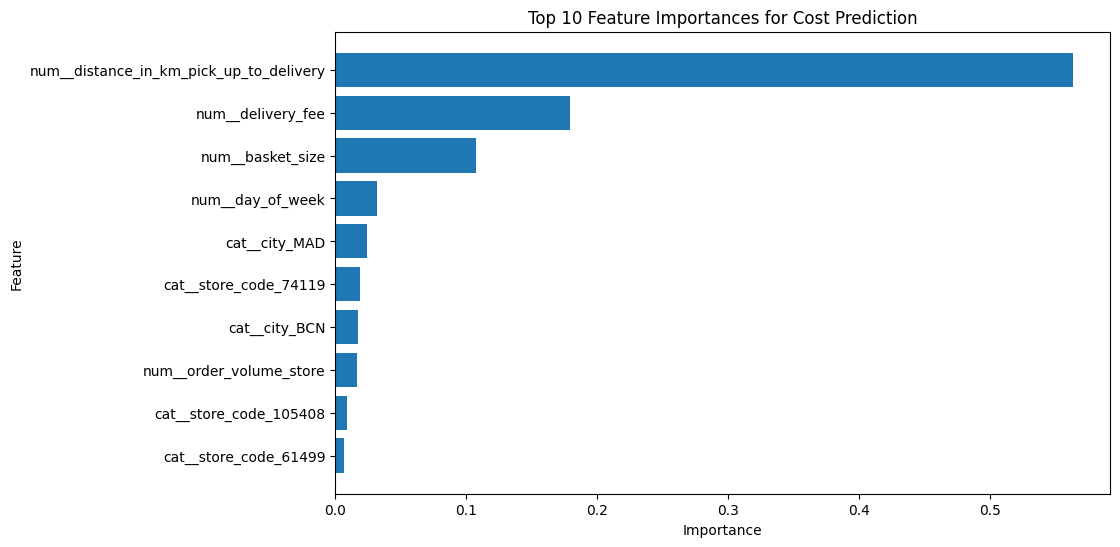

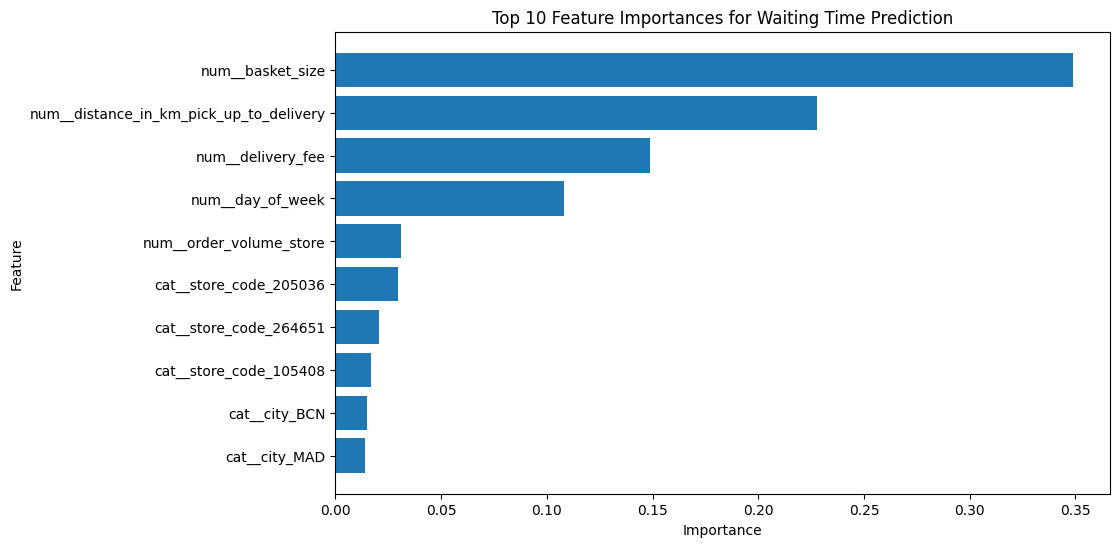

In [21]:
# Plot cost feature importance
plt.figure(figsize=(10, 6))
plt.barh(cost_importance.head(10)["feature"][::-1], cost_importance.head(10)["importance"][::-1])
plt.title("Top 10 Feature Importances for Cost Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Plot wait feature importance
plt.figure(figsize=(10, 6))
plt.barh(wait_importance.head(10)["feature"][::-1], wait_importance.head(10)["importance"][::-1])
plt.title("Top 10 Feature Importances for Waiting Time Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
# ============================================================
#  INEFFICIENCY ANALYSIS USING RESIDUALS
# Residual = Actual CPO - Predicted CPO
# Positive residual means actual cost is higher than expected
# ============================================================

In [23]:
# Predict CPO for all rows
df["predicted_cpo"] = cost_pipeline.predict(X_cost)

# Create residual
df["cpo_residual"] = df["cost_per_order_cpo"] - df["predicted_cpo"]

# Summarize store inefficiency
store_inefficiency = (
    df.groupby(["city", "store_code"])
    .agg(
        orders=("order_id", "count"),
        avg_actual_cpo=("cost_per_order_cpo", "mean"),
        avg_predicted_cpo=("predicted_cpo", "mean"),
        avg_residual=("cpo_residual", "mean"),
        avg_distance_km=("distance_in_km_pick_up_to_delivery", "mean"),
        avg_wait_mins=("courier_waiting_time_mins", "mean"),
        avg_basket=("basket_size", "mean")
    )
    .reset_index()
)
# Filter stores with enough observations
min_orders = 10
store_inefficiency = store_inefficiency[store_inefficiency["orders"] >= min_orders]

top_inefficient_stores = store_inefficiency.sort_values("avg_residual", ascending=False).head(10)

print("\nTOP 10 INEFFICIENT STORES")
display(top_inefficient_stores)



TOP 10 INEFFICIENT STORES


,city,store_code,orders,avg_actual_cpo,avg_predicted_cpo,avg_residual,avg_distance_km,avg_wait_mins,avg_basket
2,BCN,264651,78,3.534615,3.506465,0.028150,0.915385,2.853846,14.469231
6,BCN,74118,77,4.176623,4.149542,0.027082,1.905195,3.818182,10.870130
4,BCN,65231,89,3.816854,3.798453,0.018401,1.626966,3.787640,19.483146
1,BCN,259875,89,3.478652,3.475863,0.002788,1.308989,3.639326,19.300000
9,MAD,34310,88,2.535227,2.537082,-0.001854,0.572727,3.752273,18.268182
10,MAD,46515,89,2.805618,2.818923,-0.013305,0.801124,3.700000,18.478652
11,MAD,61499,88,4.201136,4.219416,-0.018279,2.095455,3.960227,13.634091
0,BCN,248266,89,3.516854,3.540340,-0.023486,1.412360,3.717978,19.861798
3,BCN,264652,80,3.597500,3.632296,-0.034796,1.162500,3.251250,13.935000
7,MAD,105408,89,3.682022,3.725202,-0.043180,2.423596,4.741573,19.997753


In [37]:
# ============================================================
#  OPTIMIZATION RECOMMENDATIONS
# Goal: Convert findings into business actions
# ============================================================


In [38]:
# City summary for recommendations
city_summary = (
    df.groupby("city")
    .agg(
        orders=("order_id", "count"),
        avg_cpo=("cost_per_order_cpo", "mean"),
        avg_wait=("courier_waiting_time_mins", "mean"),
        avg_distance=("distance_in_km_pick_up_to_delivery", "mean"),
        avg_basket=("basket_size", "mean"),
        pct_fee_below_cpo=("fee_minus_cpo", lambda x: (x < 0).mean() * 100)
    )
    .reset_index()
    )

print("\nCITY LEVEL SUMMARY")
display(city_summary.sort_values("avg_cpo", ascending=False))



CITY LEVEL SUMMARY


,city,orders,avg_cpo,avg_wait,avg_distance,avg_basket,pct_fee_below_cpo
0,BCN,589,3.710017,3.548727,1.458404,16.197284,99.830221
1,MAD,530,3.399623,4.099434,1.547736,15.374528,99.811321


In [26]:
# Rule based recommendations
recommendations = []

# Recommendation 1: cities with high average cost
high_cost_threshold = df["cost_per_order_cpo"].quantile(0.75)
high_wait_threshold = df["courier_waiting_time_mins"].quantile(0.75)

for _, row in city_summary.iterrows():
    city = row["city"]
    avg_cpo = row["avg_cpo"]
    avg_wait = row["avg_wait"]
    pct_underpriced = row["pct_fee_below_cpo"]

    if avg_cpo > high_cost_threshold:
        recommendations.append(f"{city}: review routing strategy because average CPO is above the upper quartile.")

    if avg_wait > high_wait_threshold:
        recommendations.append(f"{city}: investigate store operations and courier dispatch because waiting time is unusually high.")

    if pct_underpriced > 50:
        recommendations.append(f"{city}: revise delivery fee pricing because more than half of orders are priced below actual cost.")

In [27]:
print("\nOPTIMIZATION RECOMMENDATIONS")
for rec in recommendations:
    print("•", rec)


OPTIMIZATION RECOMMENDATIONS
• BCN: revise delivery fee pricing because more than half of orders are priced below actual cost.
• MAD: revise delivery fee pricing because more than half of orders are priced below actual cost.


In [41]:
# Store specific recommendations
print("\nSTORE SPECIFIC FOCUS AREAS")
for _, row in top_inefficient_stores.head(5).iterrows():
    print(
        f"• Store {row['store_code']} in {row['city']} is costing more than expected. "
        f"Average residual = {row['avg_residual']:.2f}, "
        f"Average wait = {row['avg_wait_mins']:.2f} mins."
    )



STORE SPECIFIC FOCUS AREAS
• Store 264651 in BCN is costing more than expected. Average residual = 0.03, Average wait = 2.85 mins.
• Store 74118 in BCN is costing more than expected. Average residual = 0.03, Average wait = 3.82 mins.
• Store 65231 in BCN is costing more than expected. Average residual = 0.02, Average wait = 3.79 mins.
• Store 259875 in BCN is costing more than expected. Average residual = 0.00, Average wait = 3.64 mins.
• Store 34310 in MAD is costing more than expected. Average residual = -0.00, Average wait = 3.75 mins.


In [42]:
# ============================================================
#  SCENARIO IMPACT ANALYSIS
# Goal: Simulate what happens if key factors change
# ============================================================

In [43]:
# Create a scenario dataset from the original feature set
scenario_df = df[cost_features].copy()

# Scenario 1: Reduce distance by 10%
scenario_1 = scenario_df.copy()
scenario_1["distance_in_km_pick_up_to_delivery"] = scenario_1["distance_in_km_pick_up_to_delivery"] * 0.90

# Scenario 2: Reduce distance by 20%
scenario_2 = scenario_df.copy()
scenario_2["distance_in_km_pick_up_to_delivery"] = scenario_2["distance_in_km_pick_up_to_delivery"] * 0.80

# Scenario 3: Increase delivery fee by 10%
scenario_3 = scenario_df.copy()
scenario_3["delivery_fee"] = scenario_3["delivery_fee"] * 1.10

# Scenario 4: Reduce operational load proxy by 15%
scenario_4 = scenario_df.copy()
scenario_4["order_volume_store"] = scenario_4["order_volume_store"] * 0.85


In [44]:
# Baseline predictions
baseline_cost = cost_pipeline.predict(scenario_df)
baseline_wait = wait_pipeline.predict(scenario_df)

# Scenario predictions
scenario_1_cost = cost_pipeline.predict(scenario_1)
scenario_2_cost = cost_pipeline.predict(scenario_2)
scenario_3_cost = cost_pipeline.predict(scenario_3)
scenario_4_wait = wait_pipeline.predict(scenario_4)

In [33]:
# Create a scenario summary table
scenario_summary = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Distance reduced by 10%",
        "Distance reduced by 20%",
        "Delivery fee increased by 10%",
        "Store volume reduced by 15% (wait model)"
    ],
    "Predicted Avg Cost": [
        np.mean(baseline_cost),
        np.mean(scenario_1_cost),
        np.mean(scenario_2_cost),
        np.mean(scenario_3_cost),
        np.mean(baseline_cost)  # cost not changed in scenario 4 summary line
        ],
    "Predicted Avg Waiting Time": [
        np.mean(baseline_wait),
        np.mean(wait_pipeline.predict(scenario_1)),
        np.mean(wait_pipeline.predict(scenario_2)),
        np.mean(wait_pipeline.predict(scenario_3)),
        np.mean(scenario_4_wait)
    ]
})

print("\nSCENARIO IMPACT ANALYSIS")
display(scenario_summary)


SCENARIO IMPACT ANALYSIS


,Scenario,Predicted Avg Cost,Predicted Avg Waiting Time
0,Baseline,3.584812,3.810952
1,Distance reduced by 10%,3.502885,3.723016
2,Distance reduced by 20%,3.440324,3.632028
3,Delivery fee increased by 10%,3.647799,3.755737
4,Store volume reduced by 15% (wait model),3.584812,3.839826


In [34]:
# Add impact percentages relative to baseline
baseline_avg_cost = np.mean(baseline_cost)
baseline_avg_wait = np.mean(baseline_wait)

scenario_summary["Cost Impact % vs Baseline"] = (
    (scenario_summary["Predicted Avg Cost"] - baseline_avg_cost) / baseline_avg_cost
) * 100

scenario_summary["Wait Impact % vs Baseline"] = (
    (scenario_summary["Predicted Avg Waiting Time"] - baseline_avg_wait) / baseline_avg_wait
) * 100

print("\nSCENARIO IMPACT ANALYSIS WITH PERCENT CHANGE")
display(scenario_summary)



SCENARIO IMPACT ANALYSIS WITH PERCENT CHANGE


,Scenario,Predicted Avg Cost,Predicted Avg Waiting Time,Cost Impact % vs Baseline,Wait Impact % vs Baseline
0,Baseline,3.584812,3.810952,0.000000,0.000000
1,Distance reduced by 10%,3.502885,3.723016,-2.285391,-2.307471
2,Distance reduced by 20%,3.440324,3.632028,-4.030540,-4.695013
3,Delivery fee increased by 10%,3.647799,3.755737,1.757063,-1.448862
4,Store volume reduced by 15% (wait model),3.584812,3.839826,0.000000,0.757656


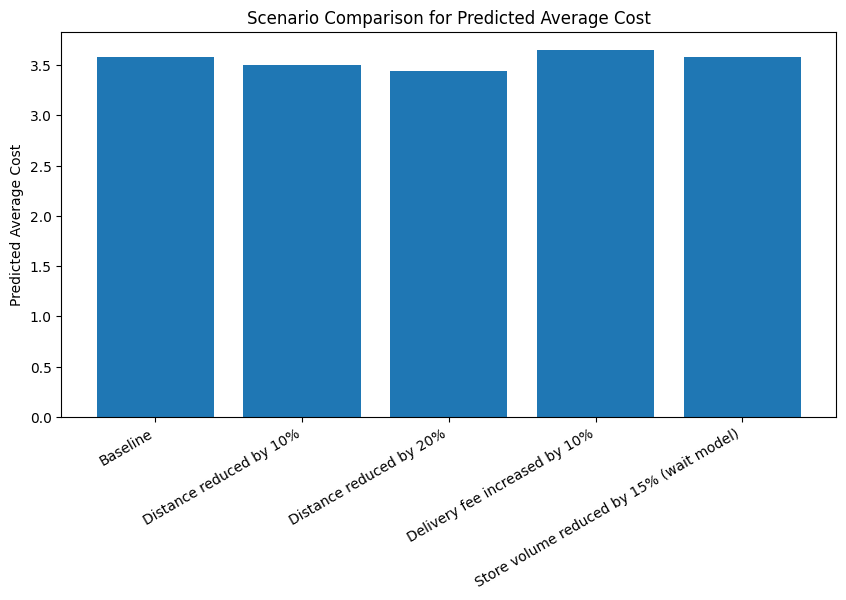

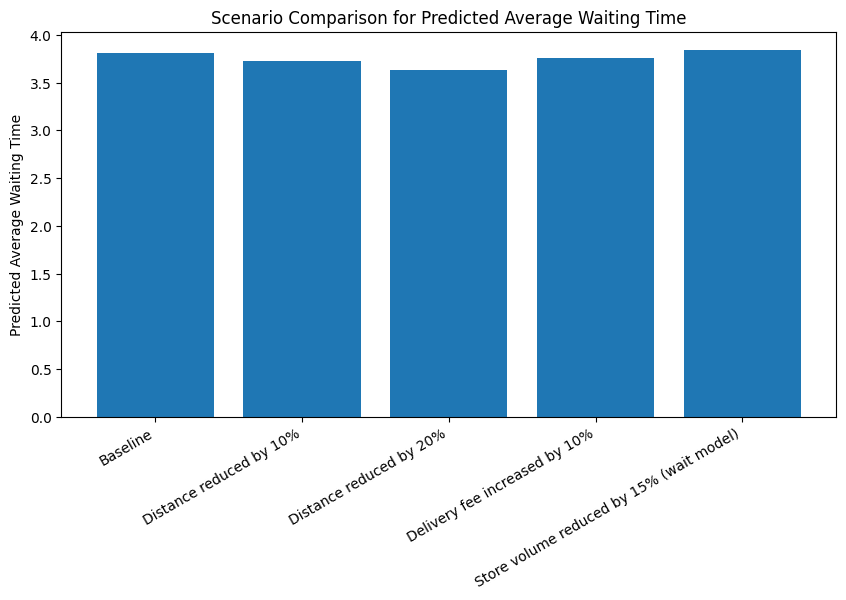

In [35]:
# Plot scenario impacts for cost
plt.figure(figsize=(10, 5))
plt.bar(scenario_summary["Scenario"], scenario_summary["Predicted Avg Cost"])
plt.title("Scenario Comparison for Predicted Average Cost")
plt.ylabel("Predicted Average Cost")
plt.xticks(rotation=30, ha="right")
plt.show()

# Plot scenario impacts for waiting time
plt.figure(figsize=(10, 5))
plt.bar(scenario_summary["Scenario"], scenario_summary["Predicted Avg Waiting Time"])
plt.title("Scenario Comparison for Predicted Average Waiting Time")
plt.ylabel("Predicted Average Waiting Time")
plt.xticks(rotation=30, ha="right")
plt.show()


In [45]:
# ============================================================
# FINAL MANAGEMENT SUMMARY
# ============================================================

print("\nFINAL MANAGEMENT SUMMARY")
print(f"Cost model MAE: {cost_mae:.3f}")
print(f"Cost model R²: {cost_r2:.3f}")
print(f"Waiting time model MAE: {wait_mae:.3f}")
print(f"Waiting time model R²: {wait_r2:.3f}")

print("\nBusiness interpretation:")
print("1. The cost prediction engine estimates delivery cost per order using city, store, basket size, fee, distance, weekday, and store volume.")
print("2. The waiting time prediction model estimates courier waiting time using the same operational features.")
print("3. Feature importance shows which variables are strongest drivers of cost and waiting time.")


FINAL MANAGEMENT SUMMARY
Cost model MAE: 0.292
Cost model R²: 0.667
Waiting time model MAE: 0.907
Waiting time model R²: 0.118

Business interpretation:
1. The cost prediction engine estimates delivery cost per order using city, store, basket size, fee, distance, weekday, and store volume.
2. The waiting time prediction model estimates courier waiting time using the same operational features.
3. Feature importance shows which variables are strongest drivers of cost and waiting time.


In [46]:
# ============================================================
# VISUALISING MODEL PREDICTIONS AND INSIGHTS
# ============================================================

import seaborn as sns
sns.set_style("whitegrid")

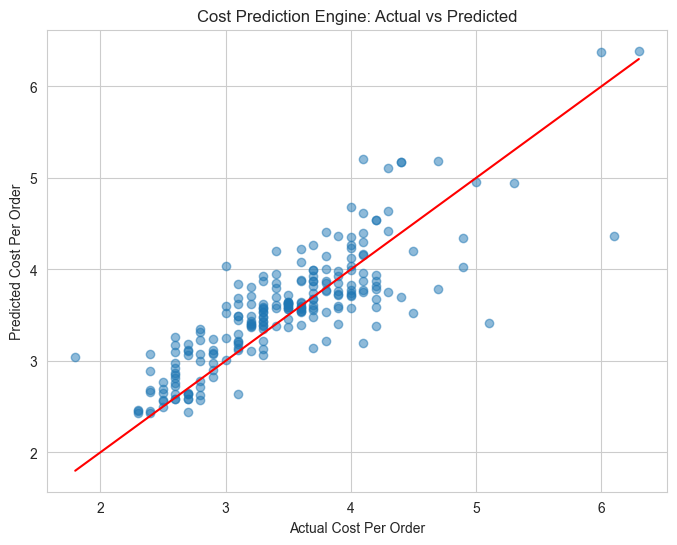

Interpretation:
Points close to the red line indicate accurate predictions.


In [48]:
# 1. ACTUAL VS PREDICTED COST (MODEL PERFORMANCE)
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(yc_test, cost_pred, alpha=0.5)

plt.plot(
    [yc_test.min(), yc_test.max()],
    [yc_test.min(), yc_test.max()],
    color='red'
)

plt.xlabel("Actual Cost Per Order")
plt.ylabel("Predicted Cost Per Order")
plt.title("Cost Prediction Engine: Actual vs Predicted")

plt.show()

print("Interpretation:")
print("Points close to the red line indicate accurate predictions.")

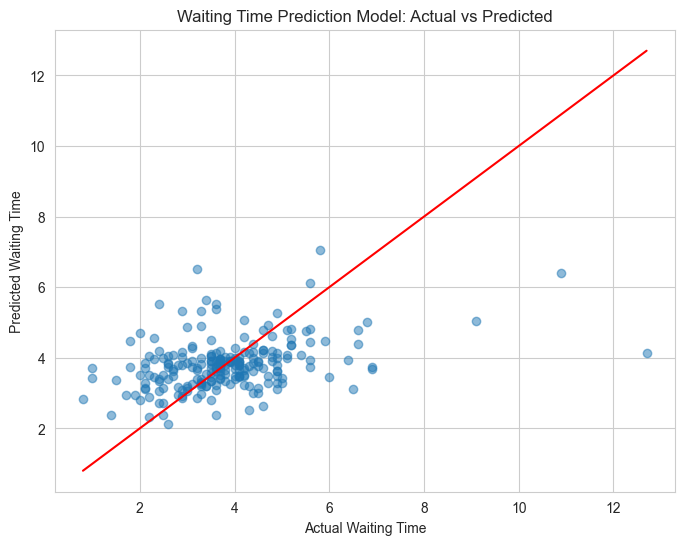

Interpretation:
Closer points to the diagonal line indicate better model accuracy.


In [49]:
# ------------------------------------------------------------
# 2. ACTUAL VS PREDICTED WAITING TIME
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(yw_test, wait_pred, alpha=0.5)

plt.plot(
    [yw_test.min(), yw_test.max()],
    [yw_test.min(), yw_test.max()],
    color='red'
)

plt.xlabel("Actual Waiting Time")
plt.ylabel("Predicted Waiting Time")
plt.title("Waiting Time Prediction Model: Actual vs Predicted")

plt.show()

print("Interpretation:")
print("Closer points to the diagonal line indicate better model accuracy.")

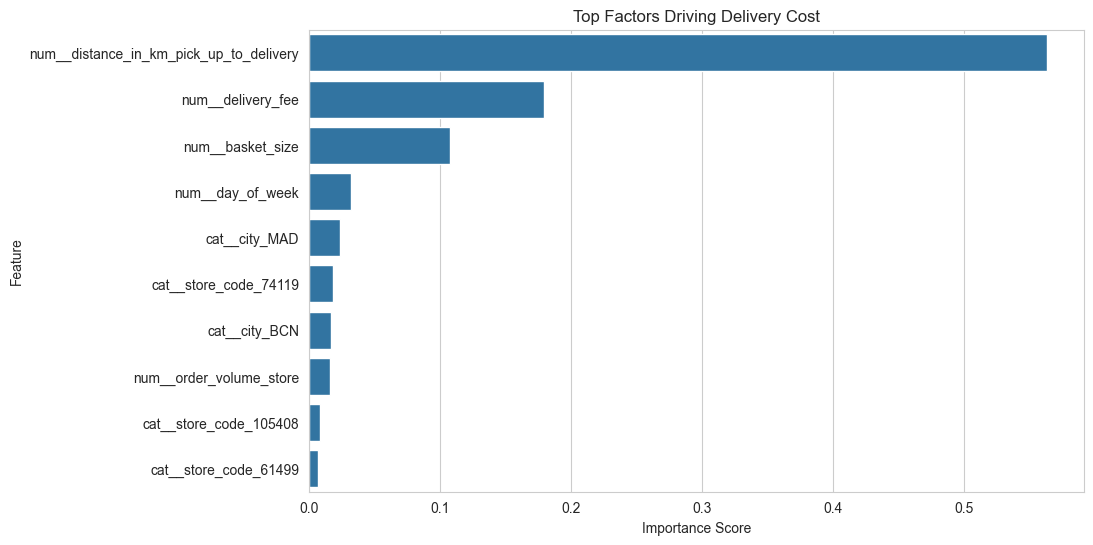

Interpretation:
Features with larger importance values influence delivery cost the most.


In [50]:
# 3. FEATURE IMPORTANCE (COST MODEL)
# ------------------------------------------------------------

top_cost_features = cost_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=top_cost_features
)

plt.title("Top Factors Driving Delivery Cost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print("Interpretation:")
print("Features with larger importance values influence delivery cost the most.")

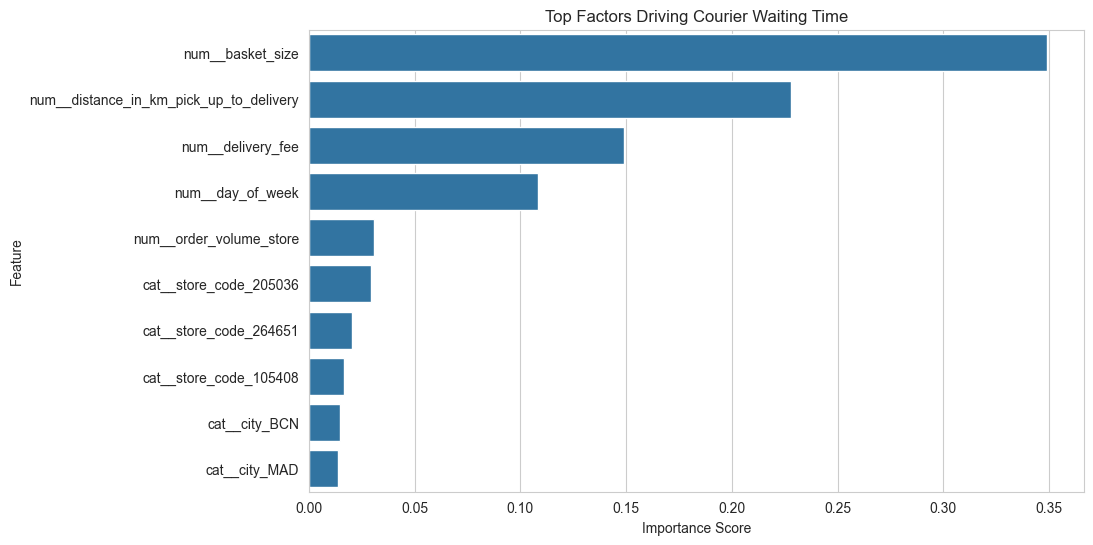

Interpretation:
These features contribute the most to waiting time variations.


In [51]:
# ------------------------------------------------------------
# 4. FEATURE IMPORTANCE (WAIT TIME MODEL)
# ------------------------------------------------------------

top_wait_features = wait_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=top_wait_features
)

plt.title("Top Factors Driving Courier Waiting Time")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

print("Interpretation:")
print("These features contribute the most to waiting time variations.")

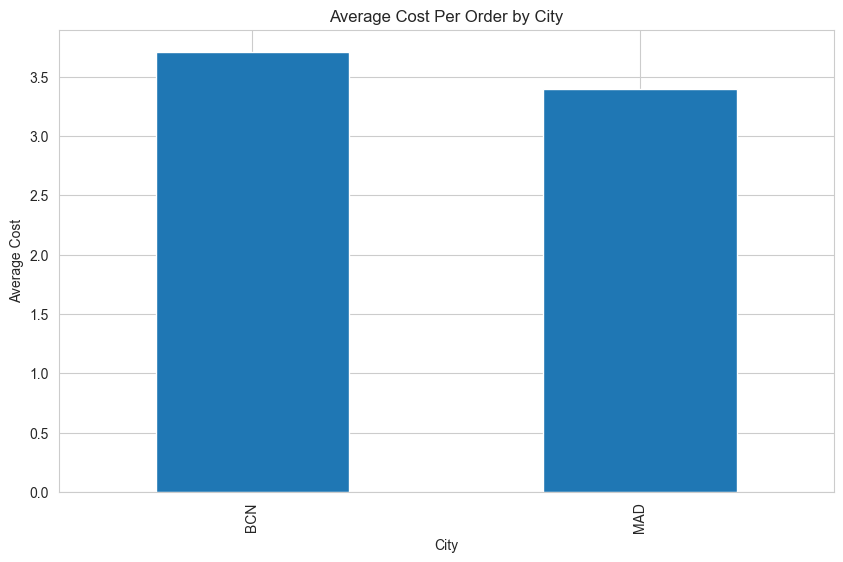

Interpretation:
Cities with higher bars have higher delivery costs.


In [52]:
# ------------------------------------------------------------
# 5. CITY COST COMPARISON
# ------------------------------------------------------------

city_cost = (
    df.groupby("city")["cost_per_order_cpo"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

city_cost.plot(kind="bar")

plt.title("Average Cost Per Order by City")
plt.xlabel("City")
plt.ylabel("Average Cost")

plt.show()

print("Interpretation:")
print("Cities with higher bars have higher delivery costs.")

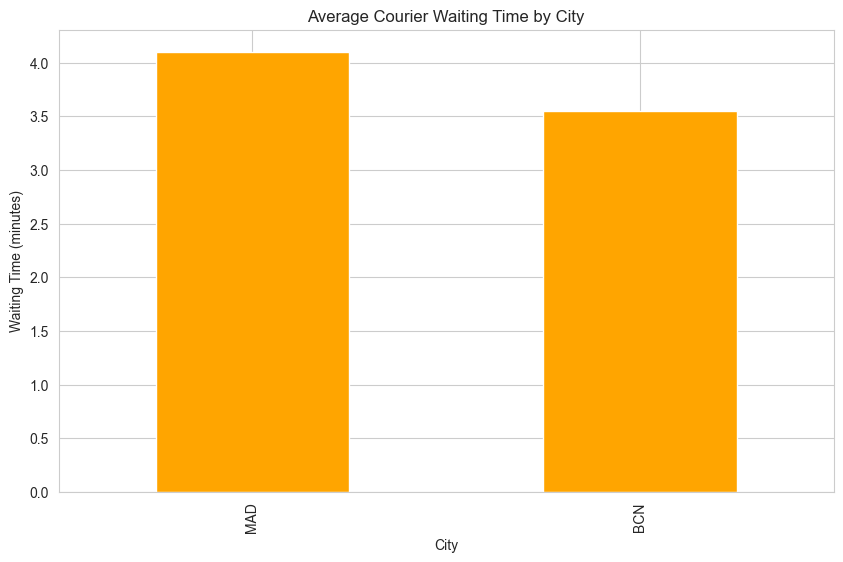

Interpretation:
Cities with higher waiting times may have operational issues.


In [54]:
# CITY WAITING TIME COMPARISON
# ------------------------------------------------------------

city_wait = (
    df.groupby("city")["courier_waiting_time_mins"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

city_wait.plot(kind="bar", color="orange")

plt.title("Average Courier Waiting Time by City")
plt.xlabel("City")
plt.ylabel("Waiting Time (minutes)")

plt.show()

print("Interpretation:")
print("Cities with higher waiting times may have operational issues.")


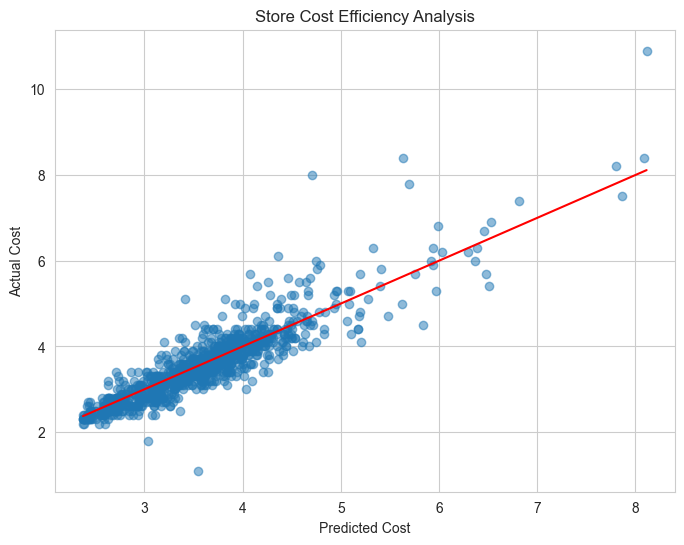

Interpretation:
Points above the line indicate stores costing more than expected.


In [55]:
 # 7. INEFFICIENT STORE DETECTION
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df["predicted_cpo"],
    df["cost_per_order_cpo"],
    alpha=0.5
)

plt.xlabel("Predicted Cost")
plt.ylabel("Actual Cost")
plt.title("Store Cost Efficiency Analysis")

plt.plot(
    [df["predicted_cpo"].min(), df["predicted_cpo"].max()],
    [df["predicted_cpo"].min(), df["predicted_cpo"].max()],
    color='red'
)

plt.show()
print("Interpretation:")
print("Points above the line indicate stores costing more than expected.")


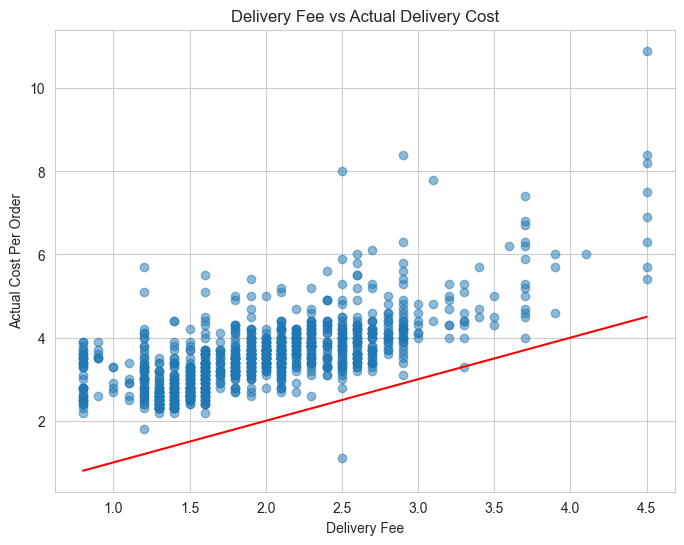

Interpretation:
Points above the line indicate deliveries where the cost exceeded the fee.


In [58]:
# ------------------------------------------------------------
# 8. DELIVERY FEE VS ACTUAL COST
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df["delivery_fee"],
    df["cost_per_order_cpo"],
    alpha=0.5
)

plt.xlabel("Delivery Fee")
plt.ylabel("Actual Cost Per Order")
plt.title("Delivery Fee vs Actual Delivery Cost")

plt.plot(
    [df["delivery_fee"].min(), df["delivery_fee"].max()],
    [df["delivery_fee"].min(), df["delivery_fee"].max()],
    color='red'
)

plt.show()

print("Interpretation:")
print("Points above the line indicate deliveries where the cost exceeded the fee.")

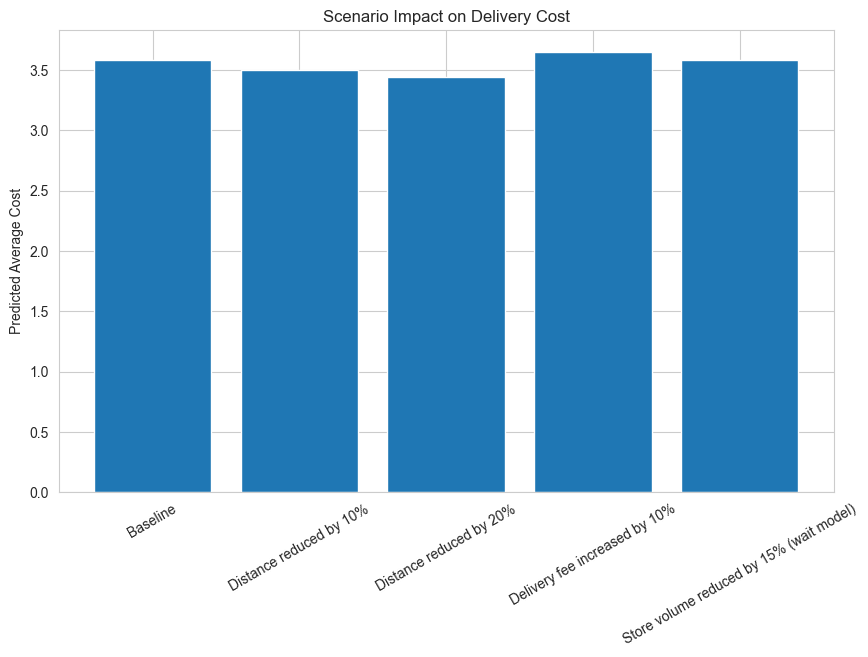

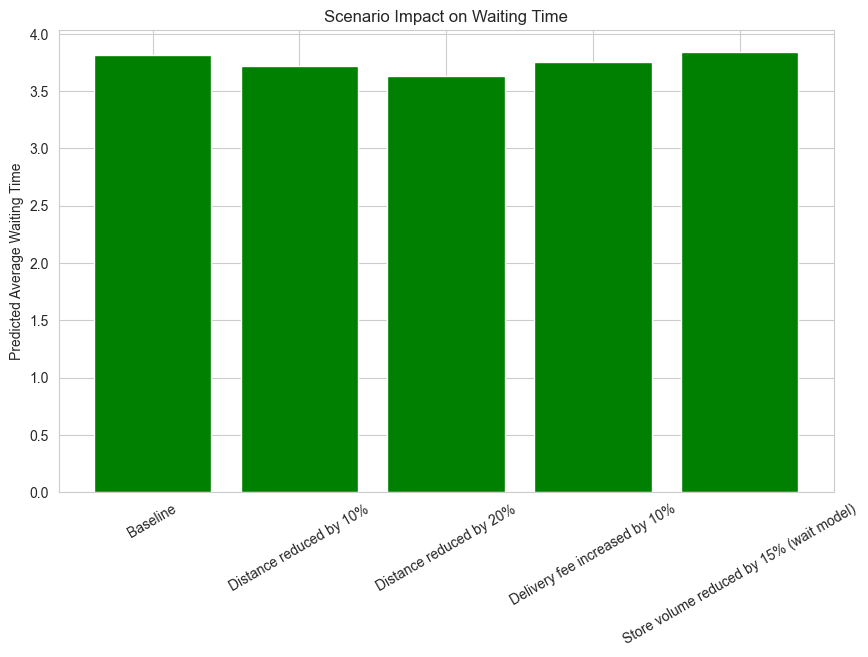

Interpretation:
These charts show how operational changes affect cost and waiting time.


In [59]:
# ------------------------------------------------------------
# 9. SCENARIO IMPACT VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["Predicted Avg Cost"]
)

plt.title("Scenario Impact on Delivery Cost")
plt.ylabel("Predicted Average Cost")
plt.xticks(rotation=30)

plt.show()

plt.figure(figsize=(10,6))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["Predicted Avg Waiting Time"],
    color="green"
)

plt.title("Scenario Impact on Waiting Time")
plt.ylabel("Predicted Average Waiting Time")
plt.xticks(rotation=30)

plt.show()

print("Interpretation:")
print("These charts show how operational changes affect cost and waiting time.")